In [1]:
# Libraries

In [1]:
!pwd

/mnt/c/Users/vvasileiou/Desktop/lncAPNet/Pilot_1_CLL/notebooks/Post-hoc_Analysis/old_colabs


In [ ]:
# Venn Diagram

In [4]:
import pandas as pd
from supervenn import supervenn
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib_venn import venn2, venn2_circles
import numpy as np
import os
from sklearn.metrics import auc

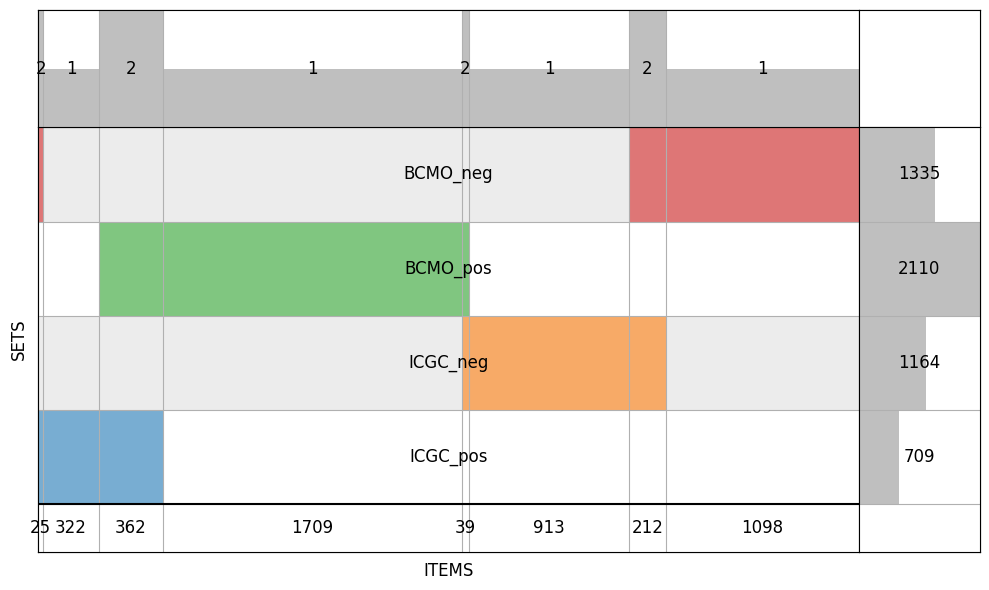

In [3]:
# Load data
icgc = pd.read_excel("../../results/ICGC/ICGC_NetBID2_ms_tab.xlsx")
bcmo = pd.read_excel("../../results/BCMO/BCMO_NetBID2_ms_tab.xlsx")

# Function to get sets by direction only (ignore funcType)
def get_set(df, direction):
    if direction == "pos":
        df_filt = df[
            (df["adj.P.Val.U.Vs.M_DA"] < 0.05) & 
            (df["logFC.U.Vs.M_DA"] > 0) & 
            (df["Size"] > 30)
        ]
    else:  # direction == "neg"
        df_filt = df[
            (df["adj.P.Val.U.Vs.M_DA"] < 0.05) & 
            (df["logFC.U.Vs.M_DA"] < 0) & 
            (df["Size"] > 30)
        ]
    return set(df_filt["originalID"].dropna())

# Define directions and datasets
directions = ["pos", "neg"]
datasets = {"ICGC": icgc, "BCMO": bcmo}

# Build sets dictionary with keys as labels and values as sets of originalID
sets = {}
for ds_name, df in datasets.items():
    for direction in directions:
        key = f"{ds_name}_{direction}"
        sets[key] = get_set(df, direction)

# Prepare lists for supervenn (expects list of sets + labels separately)
sets_list = list(sets.values())
labels = list(sets.keys())

# Plot supervenn
plt.figure(figsize=(10, 6))
supervenn(sets_list, set_annotations=labels)
plt.title("Supervenn: ICGC & BCMO by Positive/Negative")

# Get the current axes and adjust label font size
ax = plt.gca()
for label in ax.get_yticklabels():
    label.set_fontsize(8)
for label in ax.get_xticklabels():
    label.set_fontsize(8)

plt.tight_layout()
plt.savefig("../../figures/SuperVennDiagram.png", dpi=600)
plt.show()

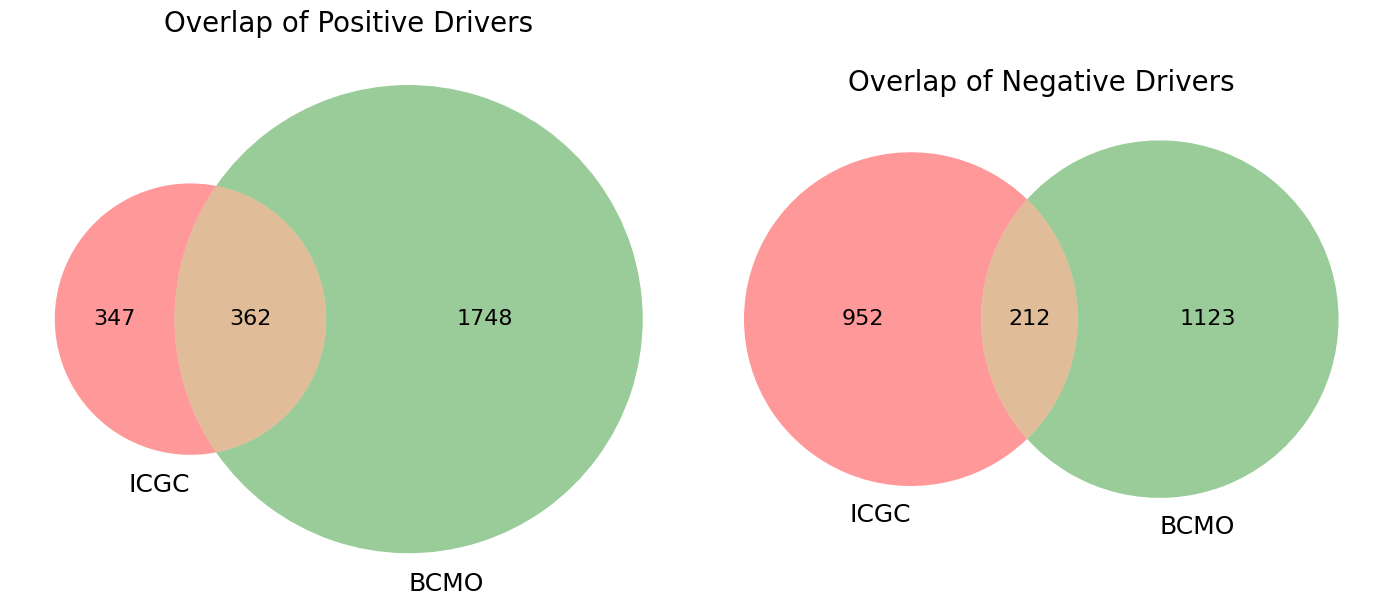

In [8]:
from matplotlib_venn import venn2
import matplotlib.pyplot as plt
import pandas as pd

# ... (your data loading and filtering code) ...

# Plot 1x2 figure with Venn diagrams
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# Function to increase font sizes in venn2
def increase_venn_font(venn, set_label_size=16, subset_size=14):
    # Set labels (ICGC, BCMO)
    for text in venn.set_labels:
        text.set_fontsize(set_label_size)
    # Set numbers inside circles
    for text in venn.subset_labels:
        if text:  # subset_labels can be None for empty subsets
            text.set_fontsize(subset_size)

# Positive Venn
v_pos = venn2([set_icgc_pos, set_bcmo_pos], set_labels=('ICGC', 'BCMO'), ax=axes[0])
increase_venn_font(v_pos, set_label_size=18, subset_size=16)
axes[0].set_title('Overlap of Positive Drivers', fontsize=20)

# Negative Venn
v_neg = venn2([set_icgc_neg, set_bcmo_neg], set_labels=('ICGC', 'BCMO'), ax=axes[1])
increase_venn_font(v_neg, set_label_size=18, subset_size=16)
axes[1].set_title('Overlap of Negative Drivers', fontsize=20)

plt.tight_layout()
plt.savefig("../../figures/VennDiagram.png", dpi=300)
plt.show()


In [ ]:
# AUC plot

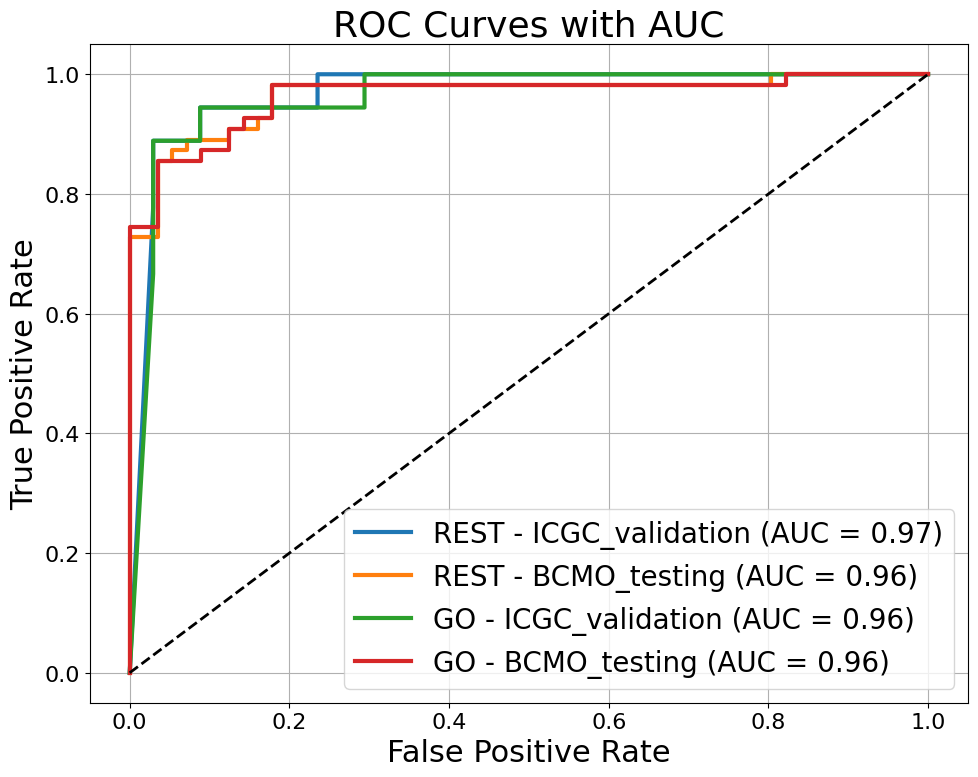

In [12]:
import os
import matplotlib.pyplot as plt
from sklearn.metrics import auc
import pandas as pd

# List of files to process
file_paths = [
    "../../PASNet/Output/REST/roc_curve_data_ICGC_validation.txt",
    "../../PASNet/Output/REST/roc_curve_data_BCMO_testing.txt",
    "../../PASNet/Output/GO/roc_curve_data_ICGC_validation.txt",
    "../../PASNet/Output/GO/roc_curve_data_BCMO_testing.txt"
]

# Plotting
plt.figure(figsize=(10, 8))

for file_path in file_paths:
    # Read the file (tab-separated, skipping comment lines)
    df = pd.read_csv(file_path, sep="\t", comment='#', names=["FPR", "TPR"])

    # Calculate AUC
    curve_auc = auc(df["FPR"], df["TPR"])

    # Generate label from file path
    method = os.path.basename(os.path.dirname(file_path))   # REST or GO
    dataset = os.path.splitext(os.path.basename(file_path))[0].replace("roc_curve_data_", "")
    label = f"{method} - {dataset} (AUC = {curve_auc:.2f})"

    # Plot the ROC curve with thicker line
    plt.plot(df["FPR"], df["TPR"], label=label, linewidth=3)

# Diagonal reference line
plt.plot([0, 1], [0, 1], 'k--', linewidth=2)

# Plot settings with larger labels and title
plt.xlabel("False Positive Rate", fontsize=22)
plt.ylabel("True Positive Rate", fontsize=22)
plt.title("ROC Curves with AUC", fontsize=26)
plt.legend(loc="lower right", fontsize=20, frameon=True)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.grid(True)
plt.tight_layout()

# Save the figure
plt.savefig("../../figures/AUC_ROC.png", dpi=600)

# Display the plot
plt.show()


In [ ]:
# F1score

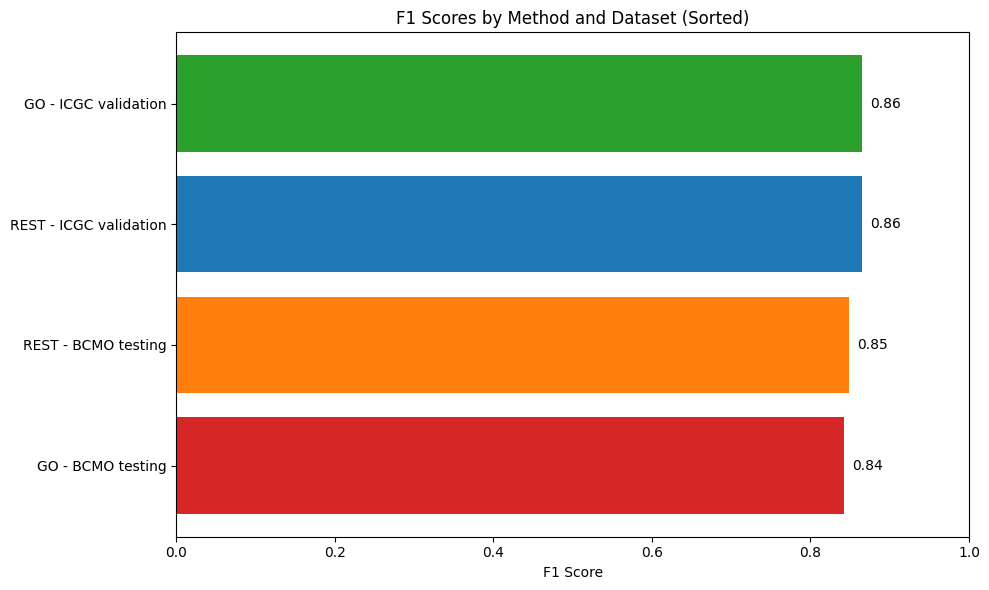

In [12]:
import matplotlib.pyplot as plt

# F1 score data
f1_scores = {
    "GO - ICGC validation": 0.8648648648648649,
    "GO - BCMO testing": 0.8421052631578947,
    "REST - ICGC validation": 0.8648648648648649,
    "REST - BCMO testing": 0.8484848484848485
}

# Specific colors for each label
color_map = {
    "REST - ICGC validation": "#1f77b4",  # Blue
    "REST - BCMO testing": "#ff7f0e",     # Orange
    "GO - BCMO testing": "#d62728",       # Red
    "GO - ICGC validation": "#2ca02c"     # Green
}

# Sort by score descending
sorted_items = sorted(f1_scores.items(), key=lambda x: x[1], reverse=True)
labels = [item[0] for item in sorted_items]
scores = [item[1] for item in sorted_items]
colors = [color_map[label] for label in labels]

# Plot
plt.figure(figsize=(10, 6))
bars = plt.barh(labels, scores, color=colors)

# Label each bar
for bar, score in zip(bars, scores):
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
             f"{score:.2f}", va='center', fontsize=10)

# Format
plt.xlim(0, 1)
plt.xlabel("F1 Score")
plt.title("F1 Scores by Method and Dataset (Sorted)")
plt.gca().invert_yaxis()  # Highest on top
plt.tight_layout()

# Save
plt.savefig("../../figures/f1_scores.png", dpi=600)

# Show
plt.show()

In [ ]:
# SHAP values

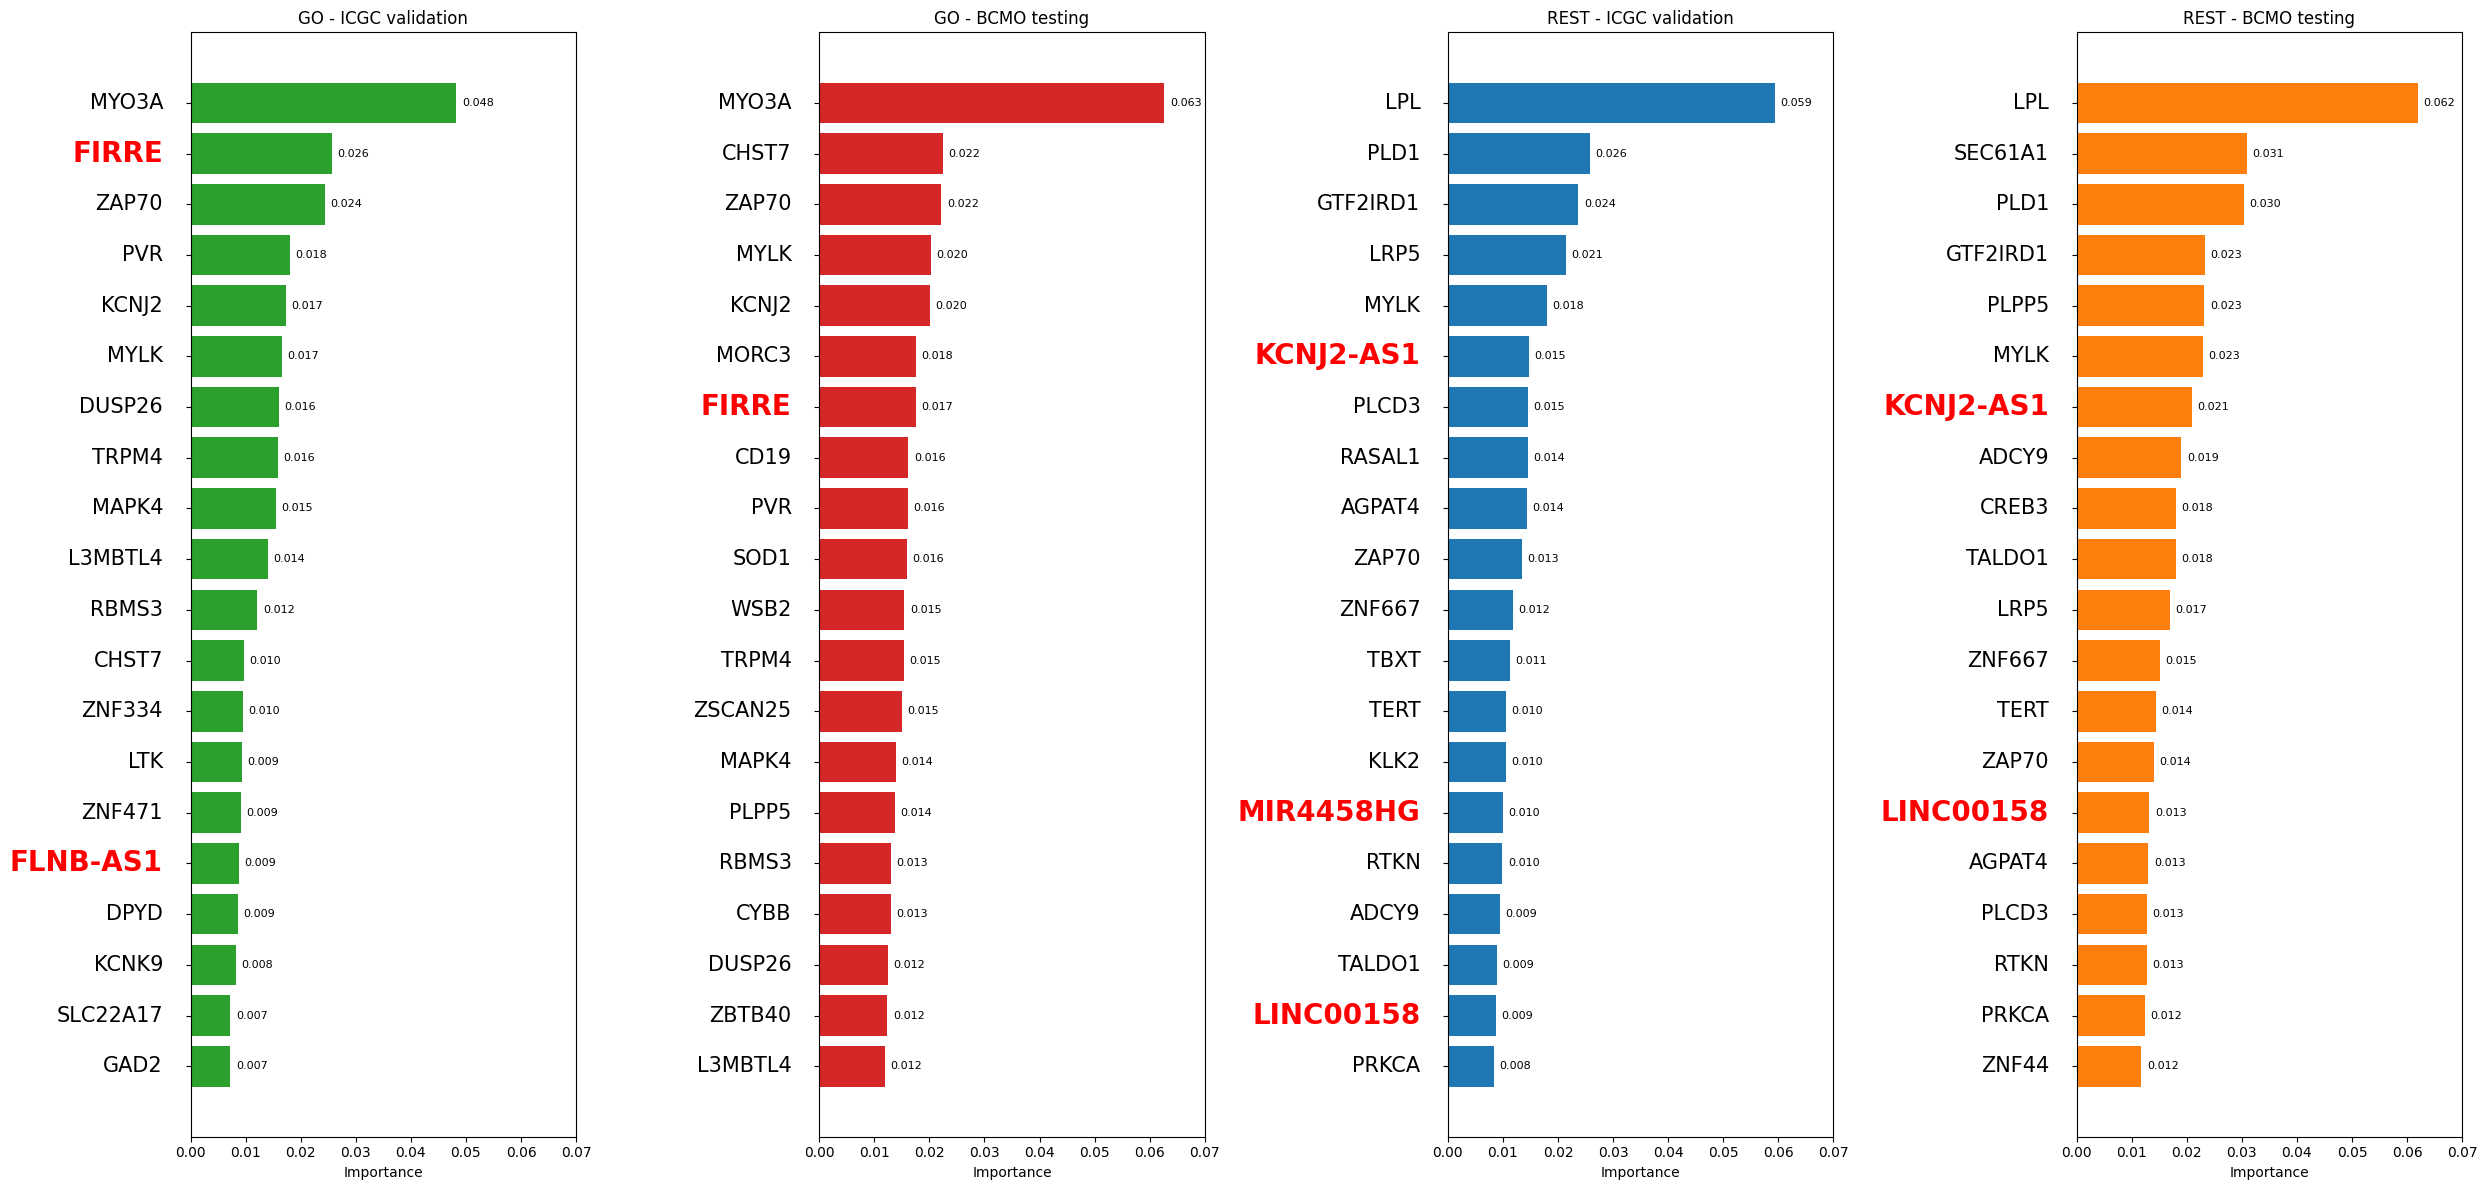

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# File paths for the feature importance tables
file_paths = {
    "GO - ICGC validation": "../../../PASNet/Output/GO/feature_importance_table_icgc_validation.csv",
    "GO - BCMO testing": "../../../PASNet/Output/GO/feature_importance_table_bcmo_testing.csv",
    "REST - ICGC validation": "../../../PASNet/Output/REST/feature_importance_table_icgc_validation.csv",
    "REST - BCMO testing": "../../../PASNet/Output/REST/feature_importance_table_bcmo_testing.csv"
}

# Color map for bars
color_map = {
    "REST - ICGC validation": "#1f77b4",
    "REST - BCMO testing": "#ff7f0e",
    "GO - BCMO testing": "#d62728",
    "GO - ICGC validation": "#2ca02c"
}

# Features to highlight
highlight_features = {"KCNJ2-AS1", "MIR4458HG", "FIRRE", "LINC00158", "FLNB-AS1"}

# Create subplots
fig, axes = plt.subplots(1, 4, figsize=(25, 12), sharex=True)

for ax, (label, path) in zip(axes, file_paths.items()):
    # Load data
    df = pd.read_csv(path)

    # Select top 20 features by importance
    top_df = df.sort_values(by='Importance', ascending=False).head(20)
    top_df = top_df[::-1]  # Reverse for horizontal bar plot

    # Plot horizontal bars
    bars = ax.barh(top_df['Feature'], top_df['Importance'], color=color_map[label])

    # Add value labels at the end of each bar
    for bar in bars:
        width = bar.get_width()
        ax.text(width + 0.001, bar.get_y() + bar.get_height() / 2,
                f"{width:.3f}", va='center', fontsize=8)

    # Set axes limits and labels
    ax.set_xlim(0, 0.07)
    ax.set_title(label)
    ax.set_xlabel("Importance")

    # Hide default y-axis labels
    ax.set_yticks(range(len(top_df)))
    ax.set_yticklabels([])

    # Add custom y-axis labels with highlighting
    for i, feature in enumerate(top_df['Feature']):
        if feature in highlight_features:
            fontweight = 'bold'
            fontsize = 20
            color = 'red'
        else:
            fontweight = 'normal'
            fontsize = 15
            color = 'black'
        ax.text(-0.005, i, feature, ha='right', va='center',
                fontweight=fontweight, fontsize=fontsize, color=color)

# Add y-axis label for the first subplot
#axes[0].set_ylabel("Feature")

# Adjust layout and save figure
plt.tight_layout()
plt.savefig("../../../figures/top20_shap_values_new.png", dpi=600)
plt.show()


In [ ]:
# Enrichment Analysis